# Customer Churn Analysis & Prediction

### Business Problem
Customer churn is a critical challenge for subscription-based businesses. When customers leave, companies lose recurring revenue and must spend more on acquiring new customers.

The objective of this analysis is to:

- Identify key factors influencing customer churn

- Analyze patterns in customer behavior

- Build a predictive model to estimate churn probability

- Segment customers based on churn risk

- Provide business recommendations to reduce churn

## Step 1 : Import the libraries

In [85]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Step 2 : Load Dataset

In [86]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3 : Dataset Overview

In [87]:
df.shape

(7043, 21)

In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [89]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Step 4 : Data Cleaning

In [90]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [92]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [93]:
df = df.dropna()

In [94]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Step 5 : Exploratory Data Analysis (EDA)

### Churn Distribution

In [95]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [96]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

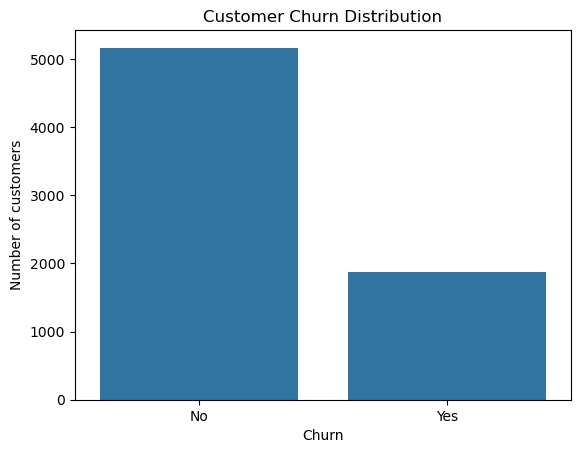

In [97]:
sns.countplot(x="Churn", data=df)
plt.ylabel("Number of customers")
plt.title("Customer Churn Distribution")
plt.show()

### Contract Type vs Churn

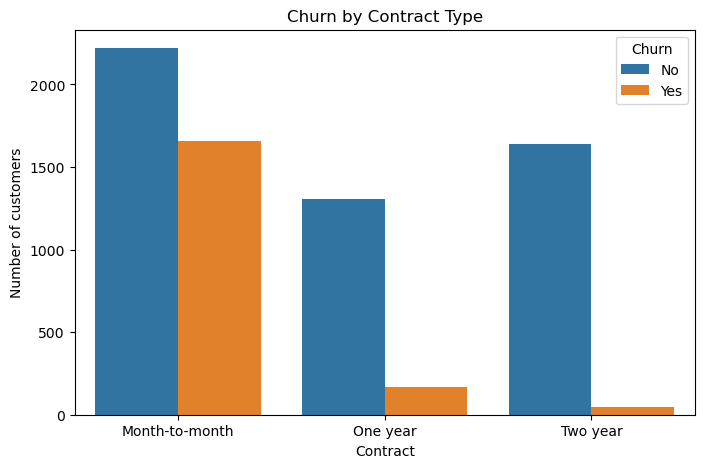

In [98]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.ylabel("Number of customers")
plt.title("Churn by Contract Type")
plt.savefig('churn_by_contract.png', dpi=300, bbox_inches='tight')

### Tenure vs Churn

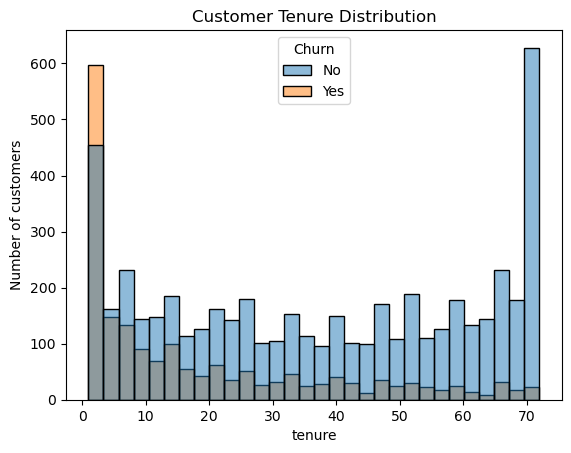

In [99]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=30)
plt.ylabel("Number of customers")
plt.title("Customer Tenure Distribution")
plt.show()

### Monthly Charges vs Churn

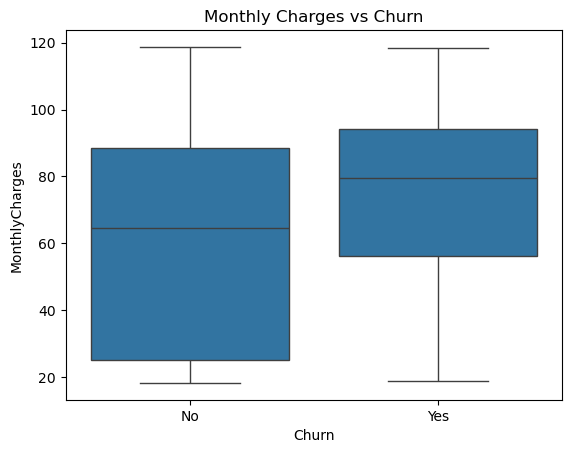

In [100]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.savefig('churn_by_monthly_charges.png', dpi=300, bbox_inches='tight')
plt.show()

### Payment Method vs Churn

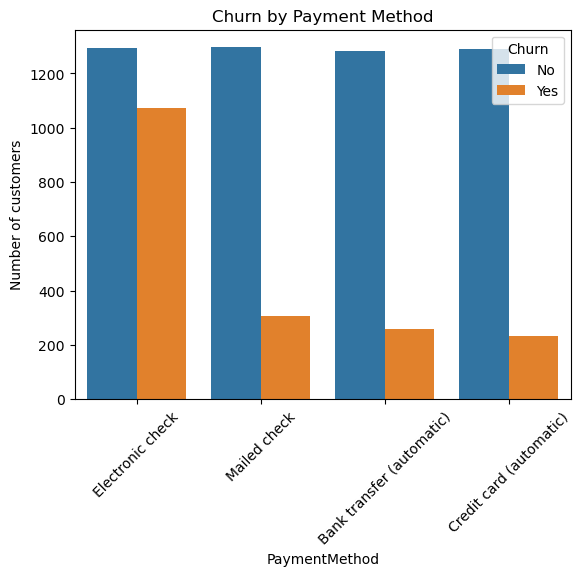

In [101]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.ylabel("Number of customers")
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.savefig('churn_by_paymentMethod.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 6 : Correlation Analysis

In [102]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [103]:
corr = df.corr(numeric_only=True)

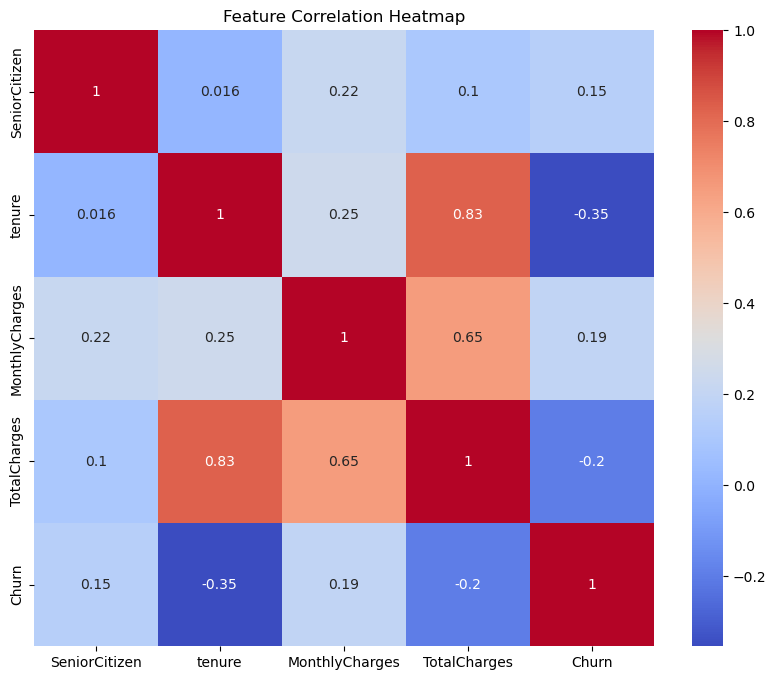

In [104]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## Step 7 : Prepare Data for Modelling

In [105]:
df_model = df.drop("customerID", axis=1)

In [106]:
df_model = pd.get_dummies(df_model, drop_first=True)

In [107]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

## Step 8 : Train Test Split

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 9 : Feature Scaling

In [109]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 10 : Train Logistic Regression Model

In [110]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Step 11 : Predictions

In [111]:
y_pred = model.predict(X_test)

## Step 12 : Model Evaluation

In [112]:
accuracy_score(y_test, y_pred)
confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Step 13 : Feature Importance

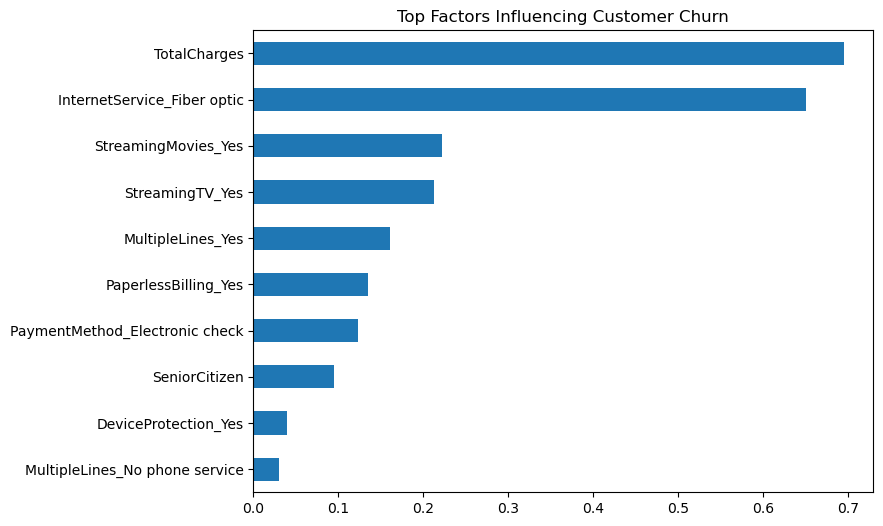

<Figure size 640x480 with 0 Axes>

In [113]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().tail(10).plot(kind="barh", figsize=(8,6))
plt.title("Top Factors Influencing Customer Churn")
plt.show()
plt.savefig('top_factors.png', dpi=300, bbox_inches='tight')

## Step 14 : Churn Probability Anaylsis

In [114]:
churn_prob = model.predict_proba(X_test)[:,1]

In [115]:
prob_df = pd.DataFrame({
    "Actual_Churn": y_test,
    "Churn_Probability": churn_prob
})

## Step 15 : Probability Distribution Plot

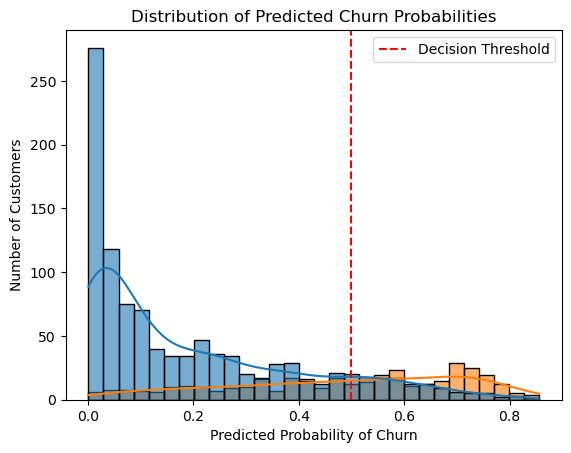

In [116]:
sns.histplot(
    data=prob_df,
    x="Churn_Probability",
    hue="Actual_Churn",
    bins=30,
    kde=True,
    alpha=0.6
)

plt.axvline(0.5, color="red", linestyle="--", label="Decision Threshold")
plt.title("Distribution of Predicted Churn Probabilities")
plt.xlabel("Predicted Probability of Churn")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()

## Step 15 : Customer Risk Segmentation

In [117]:
risk_df = pd.DataFrame({
    "Churn_Probability": churn_prob
})

In [118]:
risk_df["Risk_Level"] = pd.cut(
    risk_df["Churn_Probability"],
    bins=[0,0.3,0.6,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

In [119]:
risk_df["Risk_Level"].value_counts()

Risk_Level
Low Risk       863
Medium Risk    357
High Risk      187
Name: count, dtype: int64

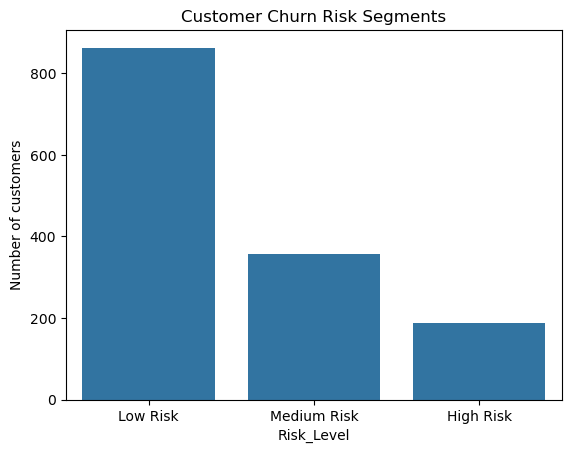

In [120]:
sns.countplot(x="Risk_Level", data=risk_df)
plt.ylabel("Number of customers")
plt.title("Customer Churn Risk Segments")
plt.savefig('churn_risk.png', dpi=300, bbox_inches='tight')
plt.show()

# Key Findings
- Customers on month-to-month contracts churn the most
- Customers with short tenure have higher churn probability
- Customers with higher monthly charges tend to churn more frequently
- Electronic check payment method shows higher churn rate

# Business Recommendations
- Encourage customers to switch to long-term contracts
- Provide targeted incentives for high-risk customers
- Improve onboarding experience for new customers
- Promote automatic payment methods to reduce churn risk

# Key Churn Drivers
Based on the analysis and model results:

- Month-to-month contracts strongly increase churn probability
- Customers with shorter tenure show higher churn risk
- Higher monthly charges correlate with increased churn
- Payment method (electronic check) shows higher churn frequency

# Conclusion
This analysis identified key behavioral patterns associated with customer churn. A logistic regression model was trained to predict churn probability and segment customers into risk groups.
These insights can help businesses:

- Identify high-risk customers early
- Implement targeted retention strategies
- Improve long-term customer engagement